**LABORATORIO: Introducción a los Biopotenciales**

ECG y EMG - Bioseñales y Sistemas

Universidad de Antioquia - Bioingeniería

Integrantes:

* Valentina García Obando Cc 1000539432
* Luis Eduardo Grajales H CC 1003293560





**5.1 Realice un esquema donde se describan y expliquen las diferentes etapas del registro de biopotenciales, desde la generación de los potenciales de acción hasta su adquisición por el equipo. Adicionalmente, describa a grandes rasgos los componentes de un equipo de adquisición.**

Imagen[1]
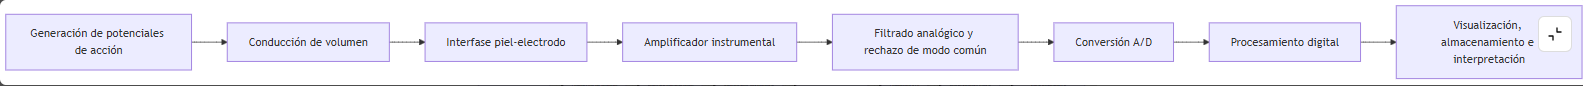

El registro de un biopotencial es una cadena de transducción que va desde la fisiología celular hasta una señal digital interpretable. Las membranas excitables generan potenciales de acción mediante intercambio iónico: en el ECG, la señal refleja la despolarización y repolarización del miocardio; en el EMG de superficie, resulta de la suma de los potenciales de múltiples unidades motoras. Estos campos eléctricos se propagan por conducción de volumen a través de tejidos con distintas propiedades eléctricas (músculo, grasa, piel y fluidos), llegando a la superficie ya atenuados y condicionados por la geometría anatómica, la posición de los electrodos y la calidad del contacto eléctrico[1].

Una vez que el campo eléctrico alcanza la piel, los electrodos lo convierten en una señal medible. Esta señal entra al front-end analógico, donde un amplificador de instrumentación con alta impedancia de entrada y alto CMRR amplifica las diferencias de potencial (del orden de µV a mV) minimizando interferencias de modo común, especialmente la red eléctrica. En ECG se complementa con el circuito de pierna derecha conducida para mejorar aún más el rechazo al ruido de red. Posteriormente, la señal se filtra analógicamente (paso alto para eliminar derivas lentas, paso bajo para limitar ruido de alta frecuencia y anti-alias antes de la digitalización) y finalmente se convierte a formato digital para su almacenamiento, detección de eventos y extracción de características[1].

Un equipo de adquisición de biopotenciales está conformado por: electrodos de registro y referencia, cables de conexión, módulo de aislamiento eléctrico, amplificador de instrumentación, filtros analógicos, convertidor A/D, microcontrolador y una interfaz de visualización o almacenamiento. En el sEMG cobran especial importancia la distancia interelectrodo, la orientación respecto a las fibras musculares y la fijación mecánica del sensor. Es importante destacar que estas etapas no son independientes: un mal contacto electrodo–piel o una ganancia mal ajustada comprometen todo el procesamiento posterior. El equipo no genera la señal, sino que debe preservar con fidelidad un fenómeno fisiológico pequeño y vulnerable a artefactos[2].


**5.2 Presente una tabla con las principales fuentes de ruido en el registro de biopotenciales. Determine ¿Cuáles de estas fuentes de ruido son estáticas o variantes en el tiempo? Indique que estrategias se utilizan para controlar o eliminar dicha fuente de ruido.**

En el registro de biopotenciales coexisten perturbaciones de naturaleza física diferente, que pueden clasificarse en tres grupos según su comportamiento temporal: componentes cuasiestáticos o de deriva lenta (offsets de electrodo, potenciales de media celda, desbalance de impedancias); perturbaciones periódicas casi estacionarias (interferencia de red eléctrica a 50/60 Hz); y artefactos no estacionarios (movimiento de electrodos, balanceo de cables, contracciones musculares no deseadas)[3]. 
Esta clasificación es relevante porque cada fuente exige una estrategia de control distinta, y la prevención física debe priorizarse sobre la corrección digital posterior[3]:

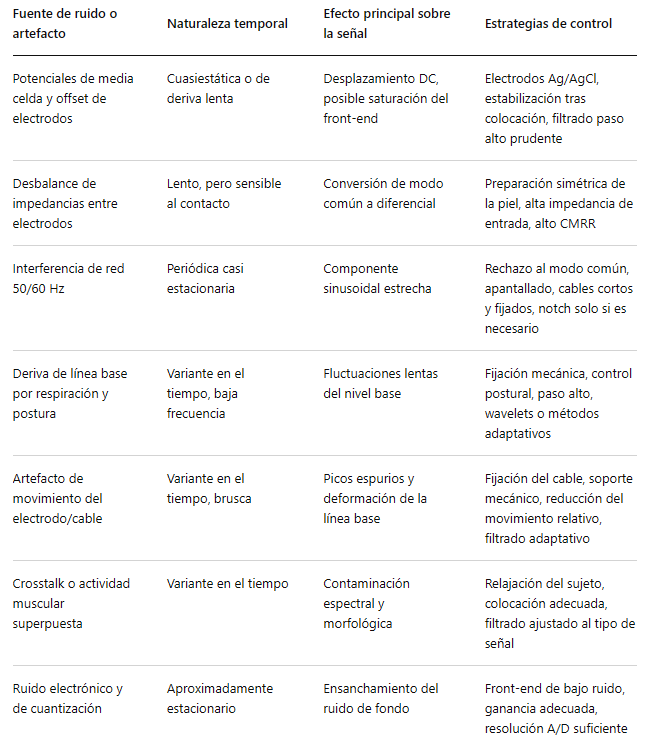

En ECG, las fuentes más críticas son la deriva de línea base y el ruido muscular, pues pueden comprometer el análisis del segmento ST, la detección de picos R y la interpretación de ondas T y Q. En EMG, el artefacto de movimiento y la interferencia de red afectan la amplitud de la envolvente y las métricas espectrales. Por ello, la estrategia óptima combina buenas prácticas de adquisición (preparación cutánea, fijación de electrodos, reducción de lazos de cable y amplificación diferencial) con un filtrado cauteloso y específico, ya que un filtrado demasiado agresivo puede eliminar información fisiológica real[4].

**5.3 Describa ¿Cuál es la problemática asociada al acoplamiento piel-electrodo? ¿Cuáles estrategias se utilizan para mejorarla? Además, responda ¿Por qué el acoplamiento piel-electrodo constituye la etapa más crítica en el registro de señales de superficie (sEMG, EEG, ECG)?**

La interfaz piel–electrodo no es un contacto simple, sino una estructura electroquímica compleja formada por el estrato córneo (barrera resistiva y capacitiva), el gel electrolito y el potencial de media celda del material del electrodo, cuya impedancia varía con la presión, hidratación, movimiento y el tiempo transcurrido tras la colocación. Esta interfaz se modela mediante resistencias y capacitancias distribuidas no lineales, lo que implica que el sistema no mide únicamente la fuente fisiológica, sino también el comportamiento eléctrico del propio contacto[5]

La interfaz piel-electrodo presenta tres problemas principales. Primero, introduce ruido y deriva, originados principalmente en la interfase electrolito-piel y dependientes del gel conductor y las propiedades cutáneas del sujeto. Segundo, la impedancia de contacto varía con el movimiento, generando artefactos que deforman la línea base y degradan la relación señal-ruido. Tercero, la asimetría entre impedancias de los canales de entrada convierte el ruido de modo común (como la interferencia de red) en señal diferencial, reduciendo la eficacia real del CMRR del amplificador. Estos problemas son especialmente críticos en registros de superficie porque la señal útil ya llega muy atenuada a la piel[5].

El acoplamiento piel–electrodo es la etapa más crítica del registro de superficie porque es el primer punto no fisiológico de la cadena de adquisición: cualquier distorsión introducida ahí será amplificada y digitalizada junto con la señal útil. Algunos errores en esta interfaz (saturación, pérdida de contacto o deformación morfológica) no son recuperables mediante procesamiento posterior. Las estrategias de mejora incluyen: limpieza y ligera abrasión de la piel, uso de electrodos Ag/AgCl, espera para estabilización del contacto, control del gel conductor y fijación del cable para reducir artefactos por movimiento. Estudios recientes confirman que la hidratación, el material del electrodo y el soporte mecánico afectan de forma apreciable la impedancia de contacto, lo que refuerza que la calidad del registro comienza antes del amplificador[6].

**5.4 Análisis de la Variabilidad de la frecuencia cardíaca (HRV)**

1. Detectar los picos R utilizando la función de la librería NeuroKit y de Detectors. ¿Cuál de los algoritmos detecta mejor los picos R?

In [3]:
! pip install neurokit2


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\luisg\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [20]:
! pip install git+https://github.com/berndporr/py-ecg-detectors.git

  Cloning https://github.com/berndporr/py-ecg-detectors.git to c:\users\luisg\appdata\local\temp\pip-req-build-nqpp7rmw
  Resolved https://github.com/berndporr/py-ecg-detectors.git to commit f39354cb686710f8e243e214b94fda0914fff656
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
     ---------------------------------------- 0.0/554.5 kB ? eta -:--:--
     -------- ----------------------------- 122.9/554.5 kB 2.4 MB/s eta 0:00:01
     ----------------------------- -------- 430.1/554.5 kB 4.5 MB/s eta 0:00:01
     -------------------------------------  553.0/554.5 kB 4.3 MB/s eta 0:00:01
     -------------------------------------- 554.5/554.5 kB 3.5 MB/s eta 0:00:00
  Installing build dependencies: started
  In

  Running command git clone --filter=blob:none --quiet https://github.com/berndporr/py-ecg-detectors.git 'C:\Users\luisg\AppData\Local\Temp\pip-req-build-nqpp7rmw'

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\luisg\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


R-peaks con NeuroKit: 14
R-peaks con Detectors: 25


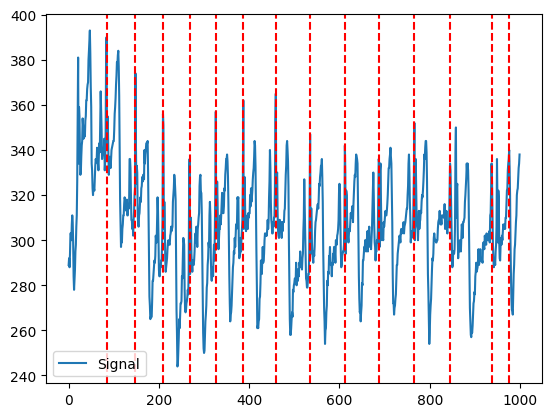

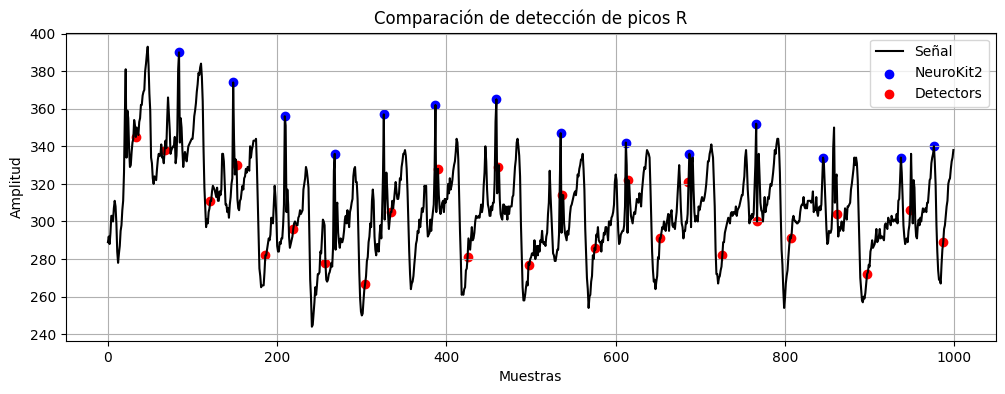

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import neurokit2 as nk
from ecgdetectors import Detectors

# 1. Cargar tu señal
data = pd.read_csv("señal_ECG.csv")

# Extraer columnas
tiempo = pd.to_numeric(data.iloc[:, 0], errors='coerce')
signal = pd.to_numeric(data.iloc[:, 1], errors='coerce')
signal = signal.dropna().values

# 2. Parámetros
fs = 100 

# 3. NeuroKit2 (picos R)
_, rpeaks_nk = nk.ecg_peaks(signal, sampling_rate=fs)

# Visualización con eventos
nk.events_plot(rpeaks_nk['ECG_R_Peaks'], signal)

# 4. Detectors (Pan-Tompkins)
detectors = Detectors(fs)
rpeaks_detector = detectors.pan_tompkins_detector(signal)

# 5. Comparación numérica
print("R-peaks con NeuroKit:", len(rpeaks_nk['ECG_R_Peaks']))
print("R-peaks con Detectors:", len(rpeaks_detector))

plt.figure(figsize=(12, 4))
plt.plot(signal, label="Señal", color="black")

plt.scatter(rpeaks_nk['ECG_R_Peaks'],
            signal[rpeaks_nk['ECG_R_Peaks']],
            color='blue', label="NeuroKit2")

plt.scatter(rpeaks_detector,
            signal[rpeaks_detector],
            color='red', label="Detectors")

plt.legend()
plt.title("Comparación de detección de picos R")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.grid()

plt.show()

A partir de la gráfica obtenida, se observa que el método de NeuroKit2 presenta una mejor correspondencia con los máximos locales de la señal, ubicando los picos en posiciones coherentes con eventos de alta amplitud. En contraste, el algoritmo de Pan-Tompkins evidencia una mayor dispersión en las detecciones, identificando múltiples puntos que no coinciden con máximos prominentes, lo que sugiere la presencia de falsos positivos.

Esta diferencia en desempeño puede explicarse por la naturaleza de ambos métodos. NeuroKit2 incorpora etapas de preprocesamiento, incluyendo filtrado y normalización de la señal, lo que le permite adaptarse mejor a condiciones no ideales. Por otro lado, el algoritmo de Pan-Tompkins, aunque ampliamente utilizado, fue diseñado bajo supuestos de señales ECG relativamente limpias y con morfología bien definida, lo que limitando su desempeño frente a ruido o señales atípicas.

Adicionalmente, la señal analizada no presenta una morfología característica de un electrocardiograma convencional, ya que no se identifican complejos QRS claramente definidos ni periodicidad consistente. Esta condición afecta directamente el desempeño de los algoritmos, incrementando la probabilidad de detecciones erróneas, especialmente en métodos sensibles al ruido como Pan-Tompkins.

2. Calcular la variabilidad de la frecuencia cardíaca (HRV) a partir de los picos R detectados

C:\Users\luisg\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
C:\Users\luisg\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\neurokit2\complexity\entropy_multiscale.py:346: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapezoid(mse) / len(mse)
C:\Users\luisg\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\neurokit2\complexity\optim_complexity_k.py:134: RuntimeWarning: divide by zero encountered in divide
  normalization = (n - 1) / 

   HRV_MeanNN    HRV_SDNN  HRV_SDANN1  HRV_SDNNI1  HRV_SDANN2  HRV_SDNNI2  \
0  686.153846  134.135408         NaN         NaN         NaN         NaN   

   HRV_SDANN5  HRV_SDNNI5   HRV_RMSSD    HRV_SDSD  HRV_CVNN  HRV_CVSD  \
0         NaN         NaN  162.249807  168.061587  0.195489  0.236463   

   HRV_MedianNN  HRV_MadNN  HRV_MCVNN  HRV_IQRNN  HRV_SDRMSSD  HRV_Prc20NN  \
0         720.0    118.608   0.164733      160.0     0.826722        598.0   

   HRV_Prc80NN  HRV_pNN50  HRV_pNN20  HRV_MinNN  HRV_MaxNN  HRV_HTI  HRV_TINN  \
0        782.0  23.076923  53.846154      390.0      920.0      6.5  226.5625   

   HRV_ULF  HRV_VLF  HRV_LF  HRV_HF  HRV_VHF  HRV_TP  HRV_LFHF  HRV_LFn  \
0      NaN      NaN     NaN     NaN      NaN     0.0       NaN      NaN   

   HRV_HFn  HRV_LnHF     HRV_SD1     HRV_SD2  HRV_SD1SD2         HRV_S  \
0      NaN       NaN  118.837488  127.616554    0.931207  47644.233882   

    HRV_CSI  HRV_CVI  HRV_CSI_Modified   HRV_PIP  HRV_IALS   HRV_PSS  HRV_PAS 

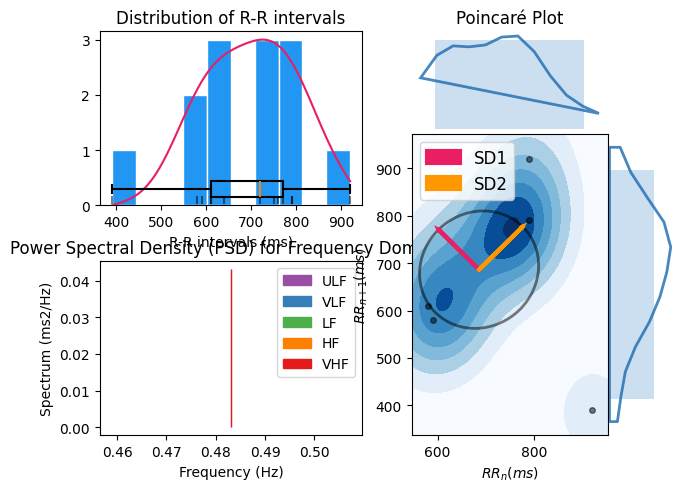

In [10]:
# Calcular HRV automáticamente
hrv = nk.hrv(rpeaks_nk, sampling_rate=fs, show=True)
print(hrv)

In [11]:
# mostrar toda la info
pd.set_option('display.max_columns', None)

# Mostrarlo en tabla
print(pd.DataFrame(hrv).T.round(3))

                                   0
HRV_MeanNN                   686.154
HRV_SDNN                     134.135
HRV_SDANN1                       NaN
HRV_SDNNI1                       NaN
HRV_SDANN2                       NaN
...                              ...
HRV_LZC                        0.854
HRV_Symbolic_EqualProb4_0V     0.091
HRV_Symbolic_EqualProb4_1V     0.636
HRV_Symbolic_EqualProb4_2LV    0.091
HRV_Symbolic_EqualProb4_2UV    0.182

[86 rows x 1 columns]


In [12]:
#Otro método

rpeaks = rpeaks_nk['ECG_R_Peaks']

# 1. Intervalos RR (en ms)
rr_intervals = np.diff(rpeaks) / fs * 1000  # convertir a milisegundos


# 2. Métricas HRV 
mean_rr = np.mean(rr_intervals)
sdnn = np.std(rr_intervals)  # variabilidad total
rmssd = np.sqrt(np.mean(np.diff(rr_intervals)**2))  # corto plazo


# 3. Frecuencia cardíaca promedio
hr = 60000 / mean_rr  # bpm

# 4. Resultados
print(f"Frecuencia cardíaca promedio: {hr:.2f} bpm")
print(f"Mean RR: {mean_rr:.2f} ms")
print(f"SDNN: {sdnn:.2f} ms")
print(f"RMSSD: {rmssd:.2f} ms")

Frecuencia cardíaca promedio: 87.44 bpm
Mean RR: 686.15 ms
SDNN: 128.87 ms
RMSSD: 162.25 ms


3. Investigar e implementar las siguientefuncion de la librería hrvanalysis para extraer características de HRV en el dominio del tiempo: get_time_domain_features

In [13]:
import numpy as np
# De forma manual, la librería hvranalysis presenta error al descargar la librería
def hrv_time_domain(rr_intervals):
    rr = np.array(rr_intervals)

    # =========================
    # Estadísticos básicos
    # =========================
    mean_nni = np.mean(rr)
    median_nni = np.median(rr)
    min_nni = np.min(rr)
    max_nni = np.max(rr)

    # =========================
    # Variabilidad global
    # =========================
    sdnn = np.std(rr, ddof=1)

    # =========================
    # Diferencias sucesivas
    # =========================
    diff_rr = np.diff(rr)

    rmssd = np.sqrt(np.mean(diff_rr**2))
    sdsd = np.std(diff_rr, ddof=1)

    # =========================
    # NN50 y pNN50
    # =========================
    nn50 = np.sum(np.abs(diff_rr) > 50)
    pnn50 = (nn50 / len(diff_rr)) * 100

    # =========================
    # Frecuencia cardíaca
    # =========================
    mean_hr = 60000 / mean_nni
    min_hr = 60000 / max_nni
    max_hr = 60000 / min_nni

    # =========================
    # Diccionario de salida
    # =========================
    features = {
        "mean_nni": mean_nni,
        "median_nni": median_nni,
        "min_nni": min_nni,
        "max_nni": max_nni,
        "sdnn": sdnn,
        "rmssd": rmssd,
        "sdsd": sdsd,
        "nn50": nn50,
        "pnn50": pnn50,
        "mean_hr": mean_hr,
        "min_hr": min_hr,
        "max_hr": max_hr
    }

    return features

In [14]:
# rr_intervals ya calculados antes (en ms)
features = hrv_time_domain(rr_intervals)

for k, v in features.items():
    print(f"{k}: {v}")

mean_nni: 686.1538461538462
median_nni: 720.0
min_nni: 390.0
max_nni: 920.0
sdnn: 134.1354080483885
rmssd: 162.24980739587951
sdsd: 168.06158683559124
nn50: 3
pnn50: 25.0
mean_hr: 87.4439461883408
min_hr: 65.21739130434783
max_hr: 153.84615384615384


Se implementó manualmente el cálculo de las métricas de variabilidad de la frecuencia cardíaca en el dominio del tiempo, replicando las funcionalidades de la función get_time_domain_features. A partir de los intervalos RR, se calcularon parámetros como SDNN, RMSSD y pNN50, los cuales permiten caracterizar la variabilidad global y de corto plazo del ritmo cardíaco. Esta implementación permite un mayor control sobre el procesamiento de la señal y evita problemas de compatibilidad asociados a librerías externas.

mean_nni → intervalo promedio entre latidos
sdnn → variabilidad global (control autonómico total)
rmssd → variabilidad de corto plazo (parasimpático)
nn50 / pnn50 → cambios bruscos entre latidos
mean_hr → frecuencia cardíaca promedio

**5.5 Consulte tres aplicaciones clínicas del uso de ECG y EMG (seis aplicaciones en total, tres por cada tipo de señal), el tipo de registro y procesamiento que se utiliza en cada una de ellas.**

Imagen [7]

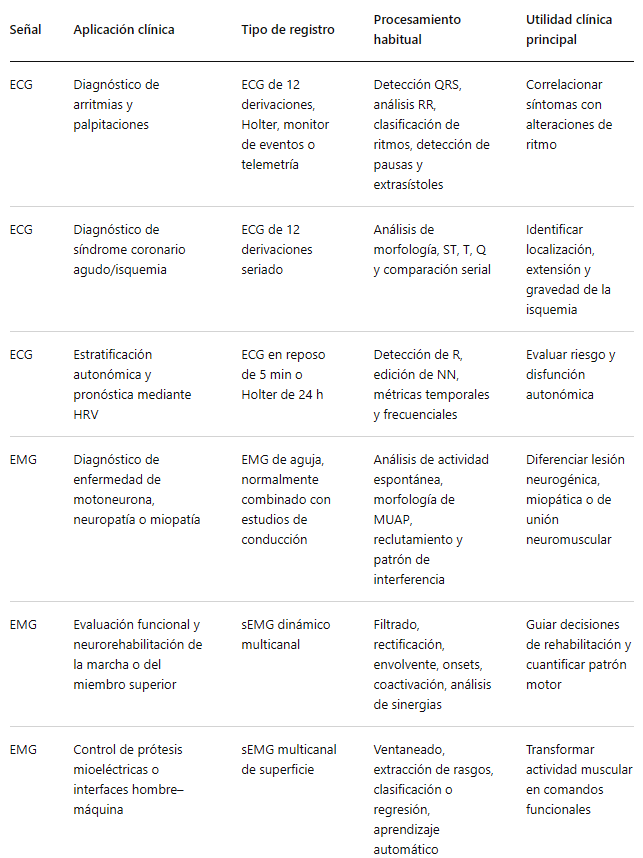

**5.6 Adjunte al menos tres conclusiones, y referencias bibliográficas apropiadas y suficientes (evitar el uso de páginas web y preferir el uso de artículos académicos)**

1. La detección de picos R mediante diferentes algoritmos evidenció variaciones significativas en el desempeño dependiendo de la calidad de la señal. El método implementado en NeuroKit2 mostró una mayor desempeñp frente al ruido y mejor alineación con los máximos locales de la señal, mientras que el algoritmo de Pan-Tompkins presentó una mayor sensibilidad a perturbaciones, generando detecciones erróneas. Esto confirma que los métodos clásicos dependen fuertemente de la calidad del ECG y de su morfología característica.[8]

2. El análisis de la variabilidad de la frecuencia cardíaca (HRV) en el dominio del tiempo permitió obtener métricas relevantes como SDNN, RMSSD y pNN50, las cuales describen la dinámica del sistema nervioso autónomo. Sin embargo, la precisión de estos indicadores está directamente condicionada por la correcta detección de los intervalos RR. En señales con baja calidad o características no típicas de ECG, los errores en la localización de los picos R se propagan, afectando la validez fisiológica de los resultados.[9]

3. La implementación manual de las métricas de HRV constituyó una alternativa efectiva frente a los problemas de compatibilidad de librerías especializadas, permitiendo comprender el cálculo de los parámetros y garantizando control total sobre el procesamiento de los datos. Este enfoque resulta especialmente útil en entornos académicos, donde la trazabilidad y comprensión del método son tan importantes como el resultado numérico.[10]

Finalmente, el análisis realizado sugiere que la señal estudiada no presenta una morfología claramente asociada a un electrocardiograma convencional, limitando la aplicabilidad directa de algoritmos diseñados para ECG. Esto resalta la importancia de una adecuada adquisición de la señal y del preprocesamiento previo al análisis, como condiciones fundamentales para obtener resultados confiables en estudios de bioseñales.

**Referencias**

[1] Kligfield, P., Gettes, L. S., Bailey, J. J., Childers, R., Deal, B. J., Hancock, E. W., van Herpen, G., & Wagner, G. S. (2007). Recommendations for the standardization and interpretation of the electrocardiogram: Part I: The electrocardiogram and its technology: A scientific statement from the American Heart Association Electrocardiography and Arrhythmias Committee, Council on Clinical Cardiology; the American College of Cardiology Foundation; and the Heart Rhythm Society. Circulation, 115(10). https://doi.org/10.1161/CIRCULATIONAHA.106.180200

[2] Merletti, R., & Cerone, G. L. (2020). Tutorial. Surface EMG detection, conditioning and pre-processing: Best practices. Journal of Electromyography and Kinesiology, 54, 102440. https://doi.org/10.1016/j.jelekin.2020.102440

[3] Pérez-Riera, A. R., Barbosa-Barros, R., Daminello-Raimundo, R., & de Abreu, L. C. (2017). Main artifacts in electrocardiography. Annals of Noninvasive Electrocardiology, 23(2), e12494. https://doi.org/10.1111/anec.12494

[4] Lenis, G., Pilia, N., Loewe, A., Schulze, W. H. W., & Dössel, O. (2017). Comparison of baseline wander removal techniques considering the preservation of ST changes in the ischemic ECG: A simulation study. Computational and Mathematical Methods in Medicine, 2017, 9295029. https://doi.org/10.1155/2017/9295029

[5] Huigen, E., Peper, A., & Grimbergen, C. A. (2002). Investigation into the origin of the noise of surface electrodes. Medical and Biological Engineering and Computing, 40, 332–338. https://doi.org/10.1007/BF02344216

[6] Murphy, B. B., Scheid, B. H., Hendricks, Q., Apollo, N. V., Litt, B., & Vitale, F. (2021). Time evolution of the skin–electrode interface impedance under different skin treatments. Sensors, 21(15), 5210. https://doi.org/10.3390/s21155210

[7] imetbaum, P., & Goldman, A. (2010). Ambulatory arrhythmia monitoring: Choosing the right device. Circulation, 122(16). https://doi.org/10.1161/CIRCULATIONAHA.109.9256107

[8] J. Pan y W. J. Tompkins, “A real-time QRS detection algorithm,” IEEE Transactions on Biomedical Engineering, vol. BME-32, no. 3, pp. 230–236, 1985.

[9] U. R. Acharya, H. Fujita, V. K. Sudarshan, S. L. Oh, M. Adam, and J. E. Koh, “Application of empirical mode decomposition (EMD) for automated identification of congestive heart failure using heart rate signals,” Neural Computing and Applications, vol. 28, pp. 3073–3094, 2017. 

[10] M. Malik et al., “Heart rate variability: Standards of measurement, physiological interpretation and clinical use,” European Heart Journal, vol. 17, no. 3, pp. 354–381, 1996.
